# 57 - Is the silver-labelling classifier's confidence honest?

Notebooks 39/41/42/55 all measured *point accuracy* (is the predicted label right or wrong at the 0.5 cutoff). This asks a different, complementary question: when the classifier says it's 90% confident, is it actually right about 90% of the time, or is that number optimistic/pessimistic? A well-calibrated classifier's confidence scores can be trusted at face value across the entire silver tier, not just at the single accuracy number already measured, that matters because most of the silver tier was never spot-checked individually.

**Avoiding circularity**: same principle as notebook 56, scoring the deployment classifier against the labels it trained on would be meaningless. This reuses leave-one-query-out cross-validation, every gold-labelled candidate is scored by a model that never saw its own query during training, then bins predicted probability against actual outcome.

In [1]:
import time
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import LeaveOneGroupOut

OUTPUT_DIR = Path("result/57_classifier_calibration_check")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RELEVANT_THRESHOLD = 2
N_BINS = 10

feature_cols = ["score_minilm", "score_linq", "score_gte", "score_bm25",
                "invrank_minilm", "invrank_linq", "invrank_gte", "invrank_bm25",
                "reranker_score", "n_channels"]

base_gold = pd.read_json("result/40_active_learning_labeling_queue/expanded_gold_labels.json")
round_gold = pd.read_json("result/42_headline_query_deepening/round_gold_labels.json")
features = pd.read_csv("result/30_learned_fusion_ranker/scored_candidates.csv")

gold = pd.concat([
    base_gold[["query_id", "domain", "gold_label"]],
    round_gold[["query_id", "domain", "gold_label"]],
], ignore_index=True).drop_duplicates(subset=["query_id", "domain"])

labeled = gold.merge(features, on=["query_id", "domain"], how="inner")
labeled["relevant"] = (labeled["gold_label"] >= RELEVANT_THRESHOLD).astype(int)
print(f"Gold-labelled candidates available for calibration: {len(labeled)} across {labeled['query_id'].nunique()} queries")

Gold-labelled candidates available for calibration: 2267 across 101 queries


In [2]:
X = labeled[feature_cols].values
y = labeled["relevant"].values
groups = labeled["query_id"].values
logo = LeaveOneGroupOut()

cv_prob = np.zeros(len(labeled))
t0 = time.time()

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    clf = HistGradientBoostingClassifier(max_iter=150, max_depth=4, class_weight="balanced", random_state=0)
    clf.fit(X[train_idx], y[train_idx])
    cv_prob[test_idx] = clf.predict_proba(X[test_idx])[:, 1]
    if (fold + 1) % 25 == 0 or (fold + 1) == 101:
        print(f"  {fold+1}/101 queries cross-validated")

labeled["cv_prob"] = cv_prob
print(f"Done in {time.time()-t0:.1f}s -- every gold-labelled candidate scored by a model that never saw its own query")

  25/101 queries cross-validated
  50/101 queries cross-validated
  75/101 queries cross-validated
  100/101 queries cross-validated
  101/101 queries cross-validated
Done in 14.8s -- every gold-labelled candidate scored by a model that never saw its own query


In [3]:
bin_edges = np.linspace(0, 1, N_BINS + 1)
labeled["prob_bin"] = pd.cut(labeled["cv_prob"], bins=bin_edges, include_lowest=True)

calibration = labeled.groupby("prob_bin", observed=True).agg(
    n=("relevant", "size"),
    mean_predicted=("cv_prob", "mean"),
    actual_relevant_rate=("relevant", "mean"),
).reset_index()
calibration["gap"] = calibration["mean_predicted"] - calibration["actual_relevant_rate"]

print("Calibration table (predicted confidence vs. actual relevant rate, per bin):")
print(calibration.to_string(index=False))
calibration.to_csv(OUTPUT_DIR / "calibration_table.csv", index=False)

brier_score = ((labeled["cv_prob"] - labeled["relevant"]) ** 2).mean()
print()
print(f"Brier score: {brier_score:.3f} (0 = perfect, 0.25 = no better than always predicting 0.5, lower is better)")

Calibration table (predicted confidence vs. actual relevant rate, per bin):
     prob_bin   n  mean_predicted  actual_relevant_rate       gap
(-0.001, 0.1]  50        0.070279              0.220000 -0.149721
   (0.1, 0.2] 161        0.149173              0.360248 -0.211075
   (0.2, 0.3] 230        0.252561              0.539130 -0.286570
   (0.3, 0.4] 314        0.351797              0.589172 -0.237375
   (0.4, 0.5] 266        0.445936              0.545113 -0.099177
   (0.5, 0.6] 203        0.552664              0.674877 -0.122213
   (0.6, 0.7] 212        0.647092              0.707547 -0.060455
   (0.7, 0.8] 187        0.749707              0.695187  0.054519
   (0.8, 0.9] 238        0.856136              0.815126  0.041010
   (0.9, 1.0] 406        0.960050              0.899015  0.061036

Brier score: 0.220 (0 = perfect, 0.25 = no better than always predicting 0.5, lower is better)


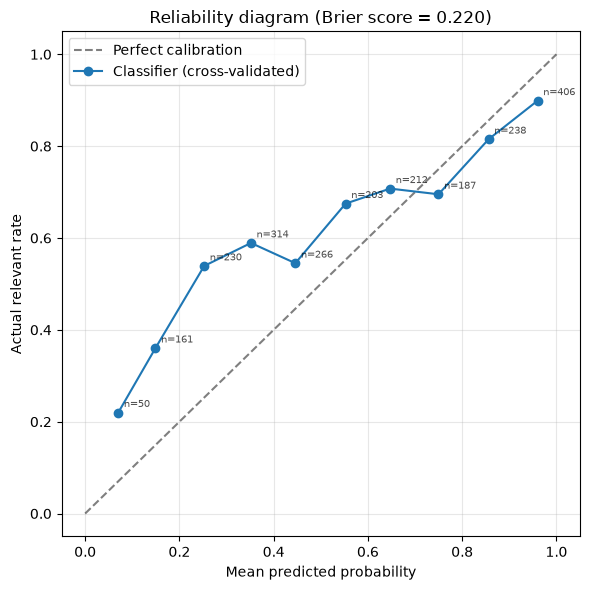

Saved -> result/57_classifier_calibration_check/reliability_diagram.png


In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
ax.plot(calibration["mean_predicted"], calibration["actual_relevant_rate"], marker="o", label="Classifier (cross-validated)")
for _, row in calibration.iterrows():
    ax.annotate(f"n={int(row['n'])}", (row["mean_predicted"], row["actual_relevant_rate"]), fontsize=7, alpha=0.7,
                    textcoords="offset points", xytext=(4, 4))
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Actual relevant rate")
ax.set_title(f"Reliability diagram (Brier score = {brier_score:.3f})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plot_path = OUTPUT_DIR / "reliability_diagram.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved -> {plot_path}")